In [28]:
# import functions from functions.py
from functions import *

## Use functions.py

In [29]:
def testing_kernel(X, y, num_topics, ker, lam, max_iter, random_state):
    '''
    Sample function for using all algorithms in functions.py
    
    Parameters:
    X: data matrix of shape (num_samples, num_features)
    y: 1d array of labels
    num_topics: number of topics for NMF
    ker: kernel for Kernel SSNMF
    lam: lambda for Kernel SSNMF and SSNMF
    max_iter: max iterations for Kernel SSNMF, Convex NMF, and SSNMF

    Returns: list of test accuracies of kernel SSNMF, convex NMF, and SSNMF
    '''
    # Define train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

    # Semi NMF initialization
    F, G = semiNMF(X_train, num_topics, max_iter)

    # Kernel SSNMF
    print('\nKernel SSNMF:', ker)
    G_train, W = KernelSSNMF(X_train, y_train, lam, G.T, max_iter, ker)
    K = kernel(X_train, ker)
    G_test = (G_train.T @ np.linalg.pinv(K) @ kernel(X=X_train, Y=X_test, kernel_type=ker)).T
    #np.linalg.pinv(W)
    print('Grid search:')
    grid_search = grid_search_svm(G_train, y_train, G_test, y_test)
    print('Best model:')
    kernel_acc = best_svm(grid_search, G_train, G_test, y_train, y_test)

    return kernel_acc

In [30]:
def testing_convex(X, y, num_topics, lam, max_iter, random_state):
    # Define train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

    # Semi NMF initialization
    F, G = semiNMF(X_train, num_topics, max_iter)
    
    # Convex NMF
    print('\nConvex NMF:')
    G_train, W = ConvexNMF(X_train, G.T, max_iter)
    XTX = X_train.T @ X_train
    G_test = (G_train.T @ np.linalg.inv(X_train @ X_train.T) @ X_train @ X_test.T).T
    #(np.linalg.pinv(W) @ X_train @ np.linalg.inv(XTX) @ X_test.T).T
    print('Grid search:')
    grid_search = grid_search_svm(G_train, y_train, G_test, y_test)
    print('Best model:')
    convex_acc = best_svm(grid_search, G_train, G_test, y_train, y_test)
    
    return convex_acc

In [31]:
def testing_ssnmf(X, y, num_topics, lam, max_iter, random_state):
    # SSNMF
    print('\nSSNMF:')
    Y_one_hot = np.zeros((y.size, y.max() + 1))
    Y_one_hot[np.arange(y.size), y] = 1
    Y = Y_one_hot
    X_nn = X - np.min(X)
    X_nn_train, X_nn_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)
    X_nn_train, X_nn_test, Y_train, Y_test = train_test_split(X_nn, Y, test_size=0.2, random_state=random_state)
    
    A, S, B, E = SSNMF(X_nn_train, Y_train, num_topics, lam, max_iter)
    S_train = (np.linalg.pinv(A) @ X_train.T).T
    S_test = (np.linalg.pinv(A) @ X_test.T).T
    print('Grid search:')
    grid_search = grid_search_svm(S_train, y_train, S_test, y_test)
    print('Best model:')
    ssnmf_acc = best_svm(grid_search, S_train, S_test, y_train, y_test)
    
    return ssnmf_acc

## Load the Embeddings

In [32]:
df = pd.read_csv('layeredSummary_df.csv', header=None)
df

,0,1,2,3,4,5,6,7,8,9,...,4598,4599,4600,4601,4602,4603,4604,4605,4606,4607
0,0.001805,-0.017398,-0.005838,-0.025201,-0.027487,0.032880,-0.002170,-0.016509,-0.035098,-0.025324,...,-0.006194,-0.009171,0.022710,-0.021053,-0.010267,0.001814,-0.005287,-0.000740,-0.027446,-0.001014
1,0.015217,0.007216,-0.001332,-0.043284,-0.024253,0.005657,0.002244,-0.005640,-0.019965,-0.030921,...,0.000235,-0.002049,0.031787,-0.029731,0.002075,-0.007838,0.004491,-0.015420,-0.022372,0.020127
2,0.004047,0.015472,0.001917,-0.033242,-0.033026,0.021729,0.013135,-0.027026,-0.023621,-0.010966,...,0.006878,-0.016094,0.006392,-0.015959,0.007898,0.000601,0.022918,-0.010135,-0.026634,-0.006189
3,-0.005267,-0.001192,0.015698,-0.031528,-0.026013,0.012542,0.012874,-0.026304,-0.028611,-0.036036,...,-0.001695,0.015300,0.016560,-0.042374,0.005837,-0.001359,-0.027047,-0.004253,-0.039085,-0.002211
4,0.006276,0.012211,0.010281,-0.027250,-0.026727,0.008491,0.008451,-0.006518,-0.031847,-0.022652,...,-0.002051,-0.019516,0.013464,-0.008565,-0.013926,0.007064,0.014865,-0.022250,0.002284,0.006782
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,0.004164,0.003739,-0.000084,-0.048068,-0.018115,0.028984,0.002493,-0.019018,-0.038964,-0.009429,...,-0.003450,-0.032090,0.028639,-0.018872,-0.010988,0.014744,0.008653,-0.023463,-0.013483,-0.012044
136,0.008245,0.009895,0.006849,-0.023689,-0.040125,0.023214,0.011838,-0.021855,-0.053164,-0.014914,...,-0.009298,-0.006574,0.022915,-0.025631,0.015770,0.004948,0.005566,0.003027,-0.025658,-0.017930
137,0.004611,-0.020028,0.003694,-0.031843,-0.016686,0.036236,0.000262,-0.015280,-0.042130,-0.045432,...,-0.010689,-0.002372,0.022266,-0.025308,-0.008159,0.005611,-0.000901,0.001431,-0.031652,0.000110
138,0.012210,0.001298,-0.016831,-0.043824,-0.035902,0.020018,0.006438,-0.022085,-0.028167,-0.023832,...,0.007022,-0.017684,0.010049,-0.015377,-0.002354,-0.015630,-0.001004,-0.012683,-0.028967,-0.007482


In [33]:
X = df.values
Y = np.vstack((np.tile([1, 0], (70, 1)), np.tile([0, 1], (70, 1))))
y = Y[:, 1] # class 0: exonerated

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
Y_one_hot = np.zeros((y.size, y.max() + 1))
Y_one_hot[np.arange(y.size), y] = 1
Y = Y_one_hot
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0)
#X_train, X_test = X_train.T, X_test.T

F, G = semiNMF(X_train, 10, 1000)

## Sample Output

In [35]:
num_topics = 5
ker = 'linear'
lam = 1
max_iter = 200
random_state = 0
kernel_acc = testing_kernel(X, y, num_topics, ker, lam, max_iter, random_state)
convex_acc = testing_convex(X, y, num_topics, lam, max_iter, random_state)
ssnmf_acc = testing_ssnmf(X, y, num_topics, lam, max_iter, random_state)


Kernel SSNMF: linear
Grid search:
Best Parameters: {'C': 100, 'gamma': 1, 'kernel': 'linear'}
Best Cross-Validation Score: 0.5541501976284585
Test Accuracy: 0.6785714285714286
Best model:
Train Accuracy: 0.5714285714285714
Test Accuracy: 0.6785714285714286

Convex NMF:
Grid search:
Best Parameters: {'C': 10, 'gamma': 1, 'kernel': 'rbf'}
Best Cross-Validation Score: 0.5537549407114624
Test Accuracy: 0.6071428571428571
Best model:
Train Accuracy: 0.6071428571428571
Test Accuracy: 0.6071428571428571

SSNMF:
Grid search:
Best Parameters: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Best Cross-Validation Score: 0.608695652173913
Test Accuracy: 0.7142857142857143
Best model:
Train Accuracy: 0.6071428571428571
Test Accuracy: 0.7142857142857143


## Vary Number of Topics and Random States

In [40]:
np.linspace(5, 15, 3)

array([ 5., 10., 15.])

In [41]:
def tuning(num_topics_range, kernel_types, random_states, X, y, lam, max_iter):
    results = {}
    for num_topics in num_topics_range:
        print('\nNumber of topics:', num_topics)
        results[num_topics] = {}
        for state in random_states:
            print('\nRandom state:', state)
            results[num_topics][state] = {}
            convex_acc = testing_convex(X, y, num_topics, lam, max_iter, state)
            ssnmf_acc = testing_ssnmf(X, y, num_topics, lam, max_iter, state)
            for ker in kernel_types:
                kernel_acc = testing_kernel(X, y, num_topics, ker, lam, max_iter, state)
                results[num_topics][state][ker] = [kernel_acc, convex_acc, ssnmf_acc]
                
    return results

kernel_types = ['linear', 'rbf', 'sigmoid', 'polynomial']
num_topics_range = np.linspace(5, 15, 3).astype(int)
#
random_states = range(40)
lam = 1
max_iter = 200
results = tuning(num_topics_range, kernel_types, random_states, X, y, lam, max_iter)


Number of topics: 5

Random state: 0

Convex NMF:
Grid search:
Best Parameters: {'C': 10, 'gamma': 1, 'kernel': 'rbf'}
Best Cross-Validation Score: 0.5537549407114624
Test Accuracy: 0.6071428571428571
Best model:
Train Accuracy: 0.6071428571428571
Test Accuracy: 0.6071428571428571

SSNMF:
Grid search:
Best Parameters: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Best Cross-Validation Score: 0.608695652173913
Test Accuracy: 0.7142857142857143
Best model:
Train Accuracy: 0.6071428571428571
Test Accuracy: 0.7142857142857143

Kernel SSNMF: linear
Grid search:
Best Parameters: {'C': 100, 'gamma': 1, 'kernel': 'linear'}
Best Cross-Validation Score: 0.5541501976284585
Test Accuracy: 0.6785714285714286
Best model:
Train Accuracy: 0.5714285714285714
Test Accuracy: 0.6785714285714286

Kernel SSNMF: rbf
Grid search:
Best Parameters: {'C': 100, 'gamma': 1, 'kernel': 'linear'}
Best Cross-Validation Score: 0.5541501976284585
Test Accuracy: 0.6428571428571429
Best model:
Train Accuracy: 0.57142857142857

/Users/xiangdilin/miniconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/Users/xiangdilin/miniconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/Users/xiangdilin/miniconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.




Kernel SSNMF: linear
Grid search:
Best Parameters: {'C': 1000, 'gamma': 1, 'kernel': 'linear'}
Best Cross-Validation Score: 0.5893280632411066
Test Accuracy: 0.5357142857142857
Best model:
Train Accuracy: 0.6160714285714286
Test Accuracy: 0.5357142857142857

Kernel SSNMF: rbf
Grid search:
Best Parameters: {'C': 1000, 'gamma': 1, 'kernel': 'linear'}
Best Cross-Validation Score: 0.5893280632411066
Test Accuracy: 0.5357142857142857
Best model:
Train Accuracy: 0.6160714285714286
Test Accuracy: 0.5357142857142857

Kernel SSNMF: sigmoid
Grid search:
Best Parameters: {'C': 1000, 'gamma': 1, 'kernel': 'linear'}
Best Cross-Validation Score: 0.5893280632411066
Test Accuracy: 0.5357142857142857
Best model:
Train Accuracy: 0.6160714285714286
Test Accuracy: 0.5357142857142857

Kernel SSNMF: polynomial
Grid search:
Best Parameters: {'C': 1000, 'gamma': 1, 'kernel': 'linear'}
Best Cross-Validation Score: 0.5893280632411066
Test Accuracy: 0.5357142857142857
Best model:
Train Accuracy: 0.6160714285714

/Users/xiangdilin/miniconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/Users/xiangdilin/miniconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/Users/xiangdilin/miniconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.




Kernel SSNMF: linear
Grid search:
Best Parameters: {'C': 1000, 'gamma': 1, 'kernel': 'linear'}
Best Cross-Validation Score: 0.5715415019762846
Test Accuracy: 0.7142857142857143
Best model:
Train Accuracy: 0.6517857142857143
Test Accuracy: 0.7142857142857143

Kernel SSNMF: rbf
Grid search:
Best Parameters: {'C': 1000, 'gamma': 1, 'kernel': 'linear'}
Best Cross-Validation Score: 0.5715415019762846
Test Accuracy: 0.7142857142857143
Best model:
Train Accuracy: 0.6517857142857143
Test Accuracy: 0.7142857142857143

Kernel SSNMF: sigmoid
Grid search:
Best Parameters: {'C': 1000, 'gamma': 1, 'kernel': 'linear'}
Best Cross-Validation Score: 0.5715415019762846
Test Accuracy: 0.7142857142857143
Best model:
Train Accuracy: 0.6517857142857143
Test Accuracy: 0.7142857142857143

Kernel SSNMF: polynomial
Grid search:
Best Parameters: {'C': 1000, 'gamma': 1, 'kernel': 'linear'}
Best Cross-Validation Score: 0.5715415019762846
Test Accuracy: 0.7142857142857143
Best model:
Train Accuracy: 0.6517857142857

...


Kernel SSNMF: linear
Grid search:
Best Parameters: {'C': 1000, 'gamma': 1, 'kernel': 'linear'}
Best Cross-Validation Score: 0.7047430830039525
Test Accuracy: 0.6071428571428571
Best model:
Train Accuracy: 0.7410714285714286
Test Accuracy: 0.6071428571428571

Kernel SSNMF: rbf
Grid search:
Best Parameters: {'C': 1000, 'gamma': 1, 'kernel': 'rbf'}
Best Cross-Validation Score: 0.6956521739130433
Test Accuracy: 0.6071428571428571
Best model:
Train Accuracy: 0.7410714285714286
Test Accuracy: 0.6071428571428571

Kernel SSNMF: sigmoid
Grid search:
Best Parameters: {'C': 1000, 'gamma': 1, 'kernel': 'rbf'}
Best Cross-Validation Score: 0.7047430830039525
Test Accuracy: 0.6071428571428571
Best model:
Train Accuracy: 0.75
Test Accuracy: 0.6071428571428571

Kernel SSNMF: polynomial
Grid search:
Best Parameters: {'C': 1000, 'gamma': 1, 'kernel': 'rbf'}
Best Cross-Validation Score: 0.7047430830039525
Test Accuracy: 0.6071428571428571
Best model:
Train Accuracy: 0.75
Test Accuracy: 0.6071428571428571

/Users/xiangdilin/miniconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/Users/xiangdilin/miniconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/Users/xiangdilin/miniconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.




Kernel SSNMF: linear
Grid search:
Best Parameters: {'C': 1000, 'gamma': 1, 'kernel': 'linear'}
Best Cross-Validation Score: 0.6083003952569169
Test Accuracy: 0.5357142857142857
Best model:
Train Accuracy: 0.7142857142857143
Test Accuracy: 0.5357142857142857

Kernel SSNMF: rbf
Grid search:
Best Parameters: {'C': 1000, 'gamma': 1, 'kernel': 'linear'}
Best Cross-Validation Score: 0.6083003952569169
Test Accuracy: 0.5357142857142857
Best model:
Train Accuracy: 0.7142857142857143
Test Accuracy: 0.5357142857142857

Kernel SSNMF: sigmoid
Grid search:
Best Parameters: {'C': 1000, 'gamma': 1, 'kernel': 'linear'}
Best Cross-Validation Score: 0.608695652173913
Test Accuracy: 0.5714285714285714
Best model:
Train Accuracy: 0.7232142857142857
Test Accuracy: 0.5714285714285714

Kernel SSNMF: polynomial
Grid search:
Best Parameters: {'C': 1000, 'gamma': 1, 'kernel': 'linear'}
Best Cross-Validation Score: 0.599604743083004
Test Accuracy: 0.5357142857142857
Best model:
Train Accuracy: 0.723214285714285

/Users/xiangdilin/miniconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/Users/xiangdilin/miniconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/Users/xiangdilin/miniconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.




Kernel SSNMF: linear
Grid search:
Best Parameters: {'C': 1000, 'gamma': 1, 'kernel': 'rbf'}
Best Cross-Validation Score: 0.7047430830039525
Test Accuracy: 0.6071428571428571
Best model:
Train Accuracy: 0.7857142857142857
Test Accuracy: 0.6071428571428571

Kernel SSNMF: rbf
Grid search:
Best Parameters: {'C': 1000, 'gamma': 1, 'kernel': 'rbf'}
Best Cross-Validation Score: 0.7047430830039525
Test Accuracy: 0.6071428571428571
Best model:
Train Accuracy: 0.7857142857142857
Test Accuracy: 0.6071428571428571

Kernel SSNMF: sigmoid
Grid search:
Best Parameters: {'C': 1000, 'gamma': 1, 'kernel': 'rbf'}
Best Cross-Validation Score: 0.6960474308300395
Test Accuracy: 0.6071428571428571
Best model:
Train Accuracy: 0.7946428571428571
Test Accuracy: 0.6071428571428571

Kernel SSNMF: polynomial
Grid search:
Best Parameters: {'C': 1000, 'gamma': 1, 'kernel': 'rbf'}
Best Cross-Validation Score: 0.6960474308300395
Test Accuracy: 0.6071428571428571
Best model:
Train Accuracy: 0.8035714285714286
Test Acc

In [42]:
results

{5: {0: {'linear': [0.6785714285714286,
    0.6071428571428571,
    0.7142857142857143],
   'rbf': [0.6428571428571429, 0.6071428571428571, 0.7142857142857143],
   'sigmoid': [0.6785714285714286, 0.6071428571428571, 0.7142857142857143],
   'polynomial': [0.6785714285714286, 0.6071428571428571, 0.7142857142857143]},
  1: {'linear': [0.5357142857142857, 0.5357142857142857, 0.35714285714285715],
   'rbf': [0.5357142857142857, 0.5357142857142857, 0.35714285714285715],
   'sigmoid': [0.5357142857142857, 0.5357142857142857, 0.35714285714285715],
   'polynomial': [0.5357142857142857,
    0.5357142857142857,
    0.35714285714285715]},
  2: {'linear': [0.6785714285714286, 0.5714285714285714, 0.6071428571428571],
   'rbf': [0.6428571428571429, 0.5714285714285714, 0.6071428571428571],
   'sigmoid': [0.6428571428571429, 0.5714285714285714, 0.6071428571428571],
   'polynomial': [0.6785714285714286, 0.5714285714285714, 0.6071428571428571]},
  3: {'linear': [0.6785714285714286, 0.6428571428571429, 0.

In [43]:
convex_results = {}
for num_topics in results:
    convex_results[num_topics] = []
    for state in results[num_topics]:
        convex_results[num_topics].append(results[num_topics][state]['linear'][1])

convex_results

{5: [0.6071428571428571,
  0.5357142857142857,
  0.5714285714285714,
  0.6428571428571429,
  0.7142857142857143,
  0.5,
  0.5714285714285714,
  0.5357142857142857,
  0.35714285714285715,
  0.5,
  0.42857142857142855,
  0.35714285714285715,
  0.75,
  0.7142857142857143,
  0.5714285714285714,
  0.6071428571428571,
  0.4642857142857143,
  0.4642857142857143,
  0.7142857142857143,
  0.4642857142857143,
  0.6071428571428571,
  0.6071428571428571,
  0.5,
  0.5,
  0.7142857142857143,
  0.5,
  0.7142857142857143,
  0.6785714285714286,
  0.8214285714285714,
  0.6428571428571429,
  0.6071428571428571,
  0.5714285714285714,
  0.7142857142857143,
  0.5357142857142857,
  0.32142857142857145,
  0.6785714285714286,
  0.5357142857142857,
  0.35714285714285715,
  0.75,
  0.5],
 10: [0.7857142857142857,
  0.4642857142857143,
  0.5714285714285714,
  0.8214285714285714,
  0.6071428571428571,
  0.5714285714285714,
  0.5357142857142857,
  0.5714285714285714,
  0.5714285714285714,
  0.5,
  0.5714285714285714

In [44]:
# Compute the average for each vector
convex_avg = {key: sum(values) / len(values) for key, values in convex_results.items()}
convex_avg

{5: 0.5732142857142857, 10: 0.63125, 15: 0.6285714285714287}

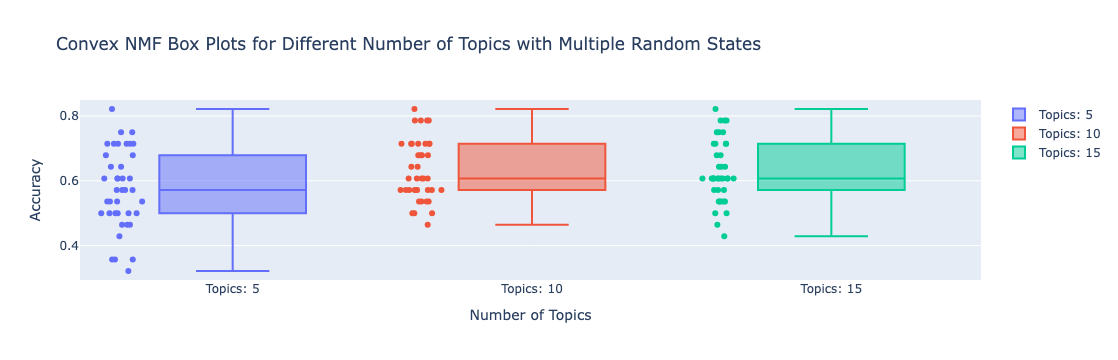

In [45]:
import plotly.graph_objects as go

# Create box plots
fig = go.Figure()

for key, values in convex_results.items():
    fig.add_trace(go.Box(y=values, name=f'Topics: {key}', boxpoints='all'))

# Update layout
fig.update_layout(
    title="Convex NMF Box Plots for Different Number of Topics with Multiple Random States",
    xaxis_title="Number of Topics",
    yaxis_title="Accuracy"
)

# Show plot
fig.show()

In [46]:
ssnmf_results = {}
for num_topics in results:
    ssnmf_results[num_topics] = []
    for state in results[num_topics]:
        ssnmf_results[num_topics].append(results[num_topics][state]['linear'][2])

ssnmf_results

{5: [0.7142857142857143,
  0.35714285714285715,
  0.6071428571428571,
  0.5,
  0.4642857142857143,
  0.5,
  0.42857142857142855,
  0.5357142857142857,
  0.39285714285714285,
  0.5714285714285714,
  0.5357142857142857,
  0.5,
  0.5,
  0.42857142857142855,
  0.39285714285714285,
  0.5,
  0.5,
  0.4642857142857143,
  0.5357142857142857,
  0.4642857142857143,
  0.39285714285714285,
  0.5357142857142857,
  0.25,
  0.35714285714285715,
  0.42857142857142855,
  0.39285714285714285,
  0.5,
  0.42857142857142855,
  0.42857142857142855,
  0.32142857142857145,
  0.4642857142857143,
  0.39285714285714285,
  0.5,
  0.35714285714285715,
  0.35714285714285715,
  0.39285714285714285,
  0.4642857142857143,
  0.35714285714285715,
  0.5,
  0.6071428571428571],
 10: [0.7857142857142857,
  0.4642857142857143,
  0.4642857142857143,
  0.42857142857142855,
  0.5357142857142857,
  0.5357142857142857,
  0.4642857142857143,
  0.42857142857142855,
  0.5714285714285714,
  0.6071428571428571,
  0.4642857142857143,


In [47]:
# Compute the average for each vector
ssnmf_avg = {key: sum(values) / len(values) for key, values in ssnmf_results.items()}
ssnmf_avg

{5: 0.4580357142857143, 10: 0.4678571428571428, 15: 0.4553571428571429}

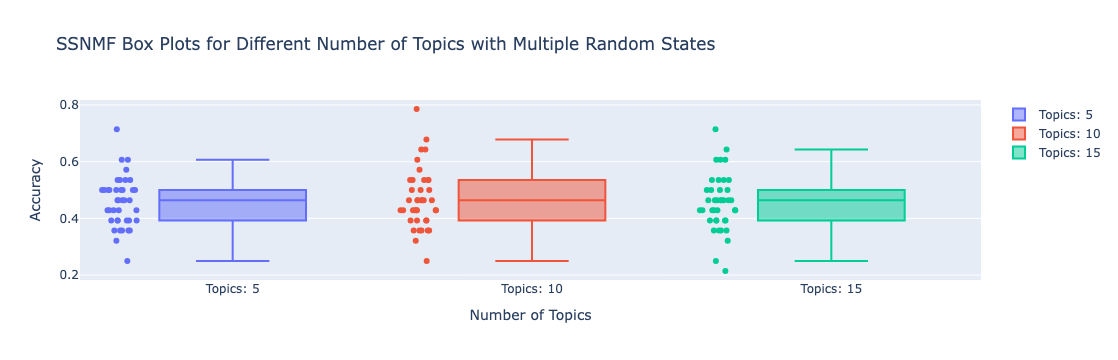

In [48]:
# Create box plots
fig = go.Figure()

for key, values in ssnmf_results.items():
    fig.add_trace(go.Box(y=values, name=f'Topics: {key}', boxpoints='all'))

# Update layout
fig.update_layout(
    title="SSNMF Box Plots for Different Number of Topics with Multiple Random States",
    xaxis_title="Number of Topics",
    yaxis_title="Accuracy"
)

# Show plot
fig.show()

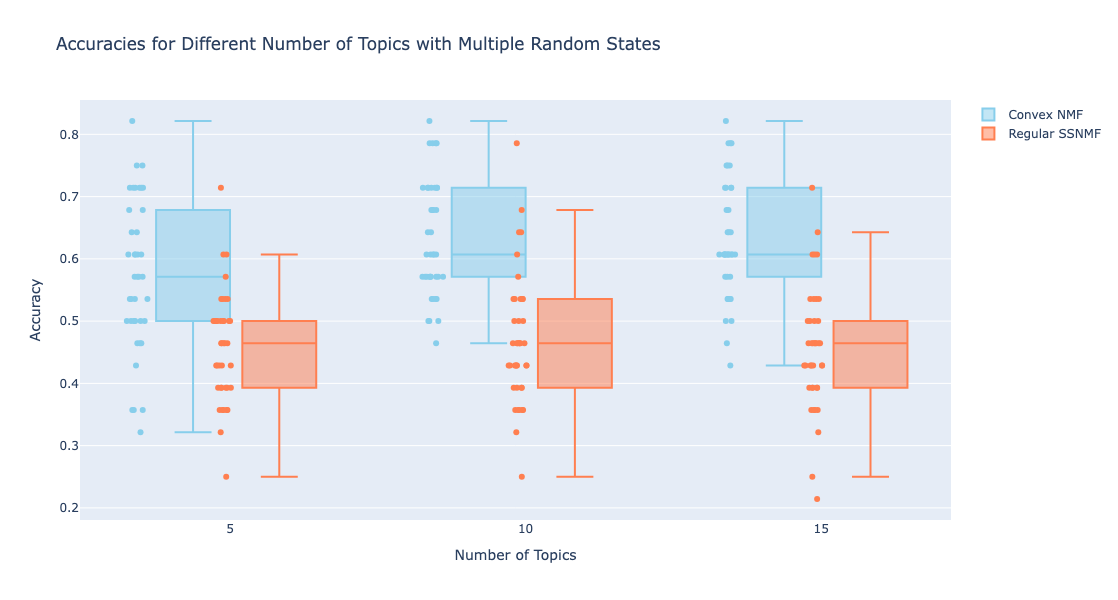

In [49]:
import plotly.graph_objects as go

# Create box plots
fig = go.Figure()

# Define spacing between groups
spacing = 0.2

# Add traces for each number of topics
first_convex = True
first_ssnmf = True

for i, key in enumerate(convex_results.keys()):
    convex_values = convex_results[key]
    ssnmf_values = ssnmf_results[key]
    
    # Calculate x position with spacing
    x_position = i * (1 + spacing)
    
    fig.add_trace(go.Box(
        y=convex_values,
        name='Convex NMF' if first_convex else None,
        boxpoints='all',
        marker_color='skyblue',
        x=[x_position] * len(convex_values),
        width=0.3, 
        showlegend=first_convex
    ))
    
    fig.add_trace(go.Box(
        y=ssnmf_values,
        name='Regular SSNMF' if first_ssnmf else None,
        boxpoints='all',
        marker_color='coral',
        x=[x_position + 0.35] * len(ssnmf_values),  # Offset for the second set
        width=0.3, 
        showlegend=first_ssnmf
    ))
    
    first_convex = False
    first_ssnmf = False

# Update layout
fig.update_layout(
    title="Accuracies for Different Number of Topics with Multiple Random States",
    xaxis_title="Number of Topics",
    yaxis_title="Accuracy",
    xaxis=dict(
        tickvals=[i * (1 + spacing) + 0.15 for i in range(len(convex_results))],  # Centered ticks
        ticktext=[str(key) for key in convex_results.keys()]
    ),
    width=800,
    height=600,
    boxmode='group'  # Group the boxes together
)

# Show plot
fig.show()


In [50]:
kernel_results = {}
for num_topics in results:
    kernel_results[num_topics] = {}
    for ker in kernel_types:
        kernel_results[num_topics][ker] = []
        for state in random_states:
            kernel_results[num_topics][ker].append(results[num_topics][state][ker][0])
kernel_results

{5: {'linear': [0.6785714285714286,
   0.5357142857142857,
   0.6785714285714286,
   0.6785714285714286,
   0.7142857142857143,
   0.5,
   0.5714285714285714,
   0.5714285714285714,
   0.42857142857142855,
   0.5,
   0.42857142857142855,
   0.32142857142857145,
   0.7857142857142857,
   0.7857142857142857,
   0.5714285714285714,
   0.5714285714285714,
   0.5,
   0.4642857142857143,
   0.7142857142857143,
   0.75,
   0.6785714285714286,
   0.6071428571428571,
   0.5,
   0.4642857142857143,
   0.75,
   0.5,
   0.6785714285714286,
   0.75,
   0.6785714285714286,
   0.6785714285714286,
   0.5714285714285714,
   0.5714285714285714,
   0.7142857142857143,
   0.6071428571428571,
   0.32142857142857145,
   0.6785714285714286,
   0.5,
   0.5357142857142857,
   0.75,
   0.5357142857142857],
  'rbf': [0.6428571428571429,
   0.5357142857142857,
   0.6428571428571429,
   0.6785714285714286,
   0.7142857142857143,
   0.5,
   0.5714285714285714,
   0.5714285714285714,
   0.4642857142857143,
   0.5,
 

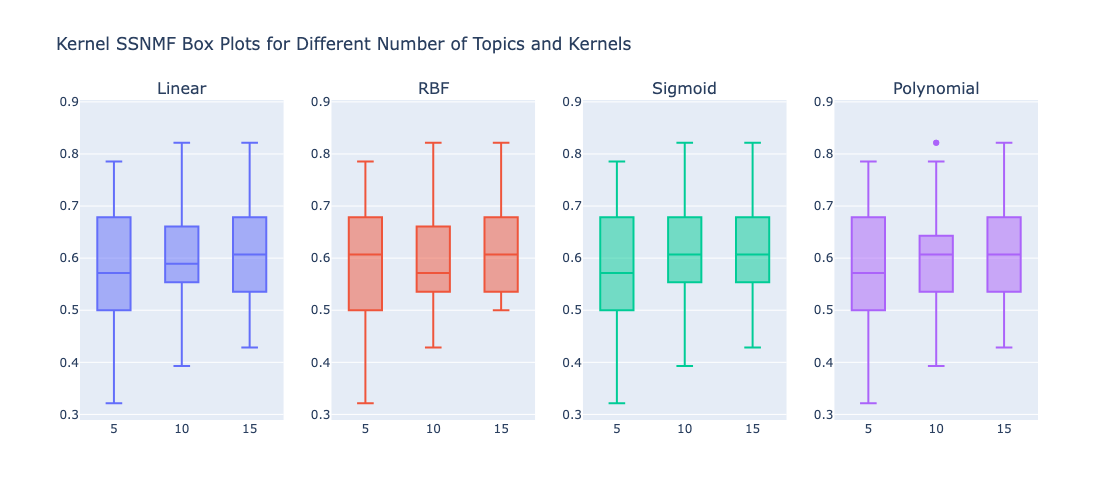

In [51]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Find the overall min and max y-values for setting a common y-axis range
all_y_values = []
for topics in kernel_results:
    for kernel in kernel_results[topics]:
        all_y_values.extend(kernel_results[topics][kernel])
y_min = min(all_y_values) * 0.9
y_max = max(all_y_values) * 1.1

# Initialize figure with subplots
fig = make_subplots(rows=1, cols=4, subplot_titles=("Linear", "RBF", "Sigmoid", "Polynomial"))

# Plot data for each kernel
kernels = ['linear', 'rbf', 'sigmoid', 'polynomial']
for i, kernel in enumerate(kernels):
    # Prepare data for each kernel
    x = []
    y = []
    for topics in kernel_results:
        x.extend([topics] * len(kernel_results[topics][kernel]))
        y.extend(kernel_results[topics][kernel])
    
    # Create box plot for each kernel
    fig.add_trace(
        go.Box(x=x, y=y, name=kernel),
        row=1, col=i+1
    )

# Update layout
fig.update_layout(
    height=500,
    width=1000,
    title_text="Kernel SSNMF Box Plots for Different Number of Topics and Kernels",
    showlegend=False,
    yaxis=dict(range=[y_min, y_max]),
    yaxis2=dict(range=[y_min, y_max]),
    yaxis3=dict(range=[y_min, y_max]),
    yaxis4=dict(range=[y_min, y_max])
)

# Show plot
fig.show()


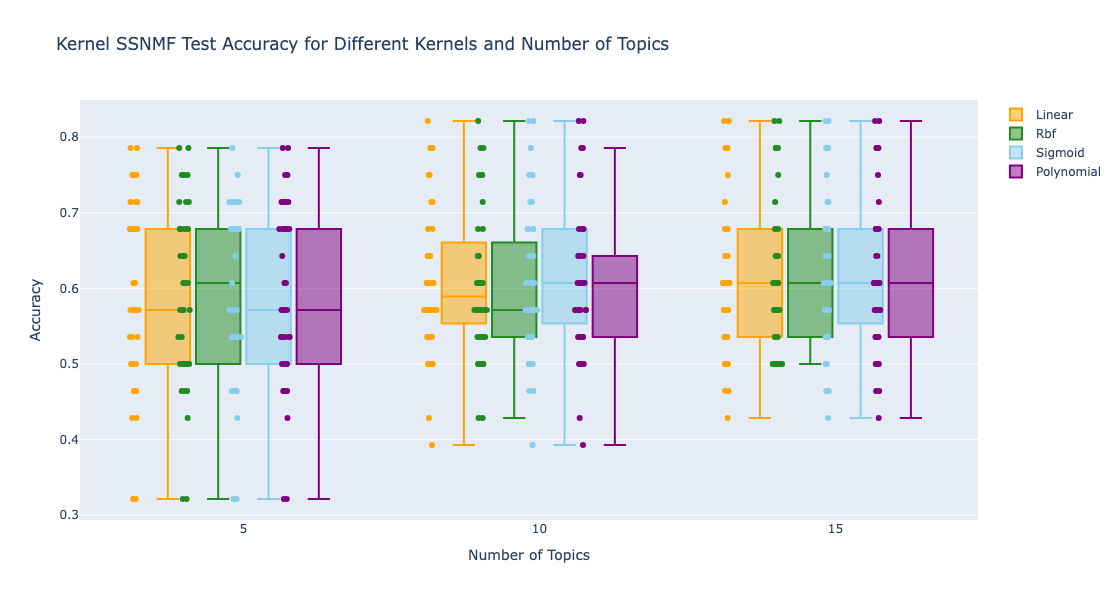

In [52]:
import plotly.graph_objects as go

# Create box plots
fig = go.Figure()

# Define kernel colors for differentiation
kernel_colors = {
    'linear': 'orange',
    'rbf': 'forestgreen',
    'sigmoid': 'skyblue',
    'polynomial': 'purple'
}

# Define width of each group of boxes and spacing between kernels
box_width = 0.15
kernel_offset = 0.17

# Add traces for each number of topics and each kernel
for i, key in enumerate(kernel_results.keys()):
    for j, kernel in enumerate(kernel_colors.keys()):
        y_values = kernel_results[key][kernel]
        
        # Calculate x position with offset for spacing
        x_pos = i + j * kernel_offset
        
        fig.add_trace(go.Box(
            y=y_values,
            name=kernel.capitalize(),
            boxpoints='all',
            marker_color=kernel_colors[kernel],
            x=[x_pos] * len(y_values),
            width=box_width,
            showlegend=(i == 0)  # Show legend only for the first set of boxes
        ))


# Update layout
fig.update_layout(
    title="Kernel SSNMF Test Accuracy for Different Kernels and Number of Topics",
    xaxis_title="Number of Topics",
    yaxis_title="Accuracy",
    xaxis=dict(
        tickvals=[i + (len(kernel_colors) - 1) * kernel_offset / 2 for i in range(len(kernel_results.keys()))],
        ticktext=[str(key) for key in kernel_results.keys()]
    ),
    boxmode='group',  # Group the boxes together
    height=600,
    width=800
)

# Show plot
fig.show()

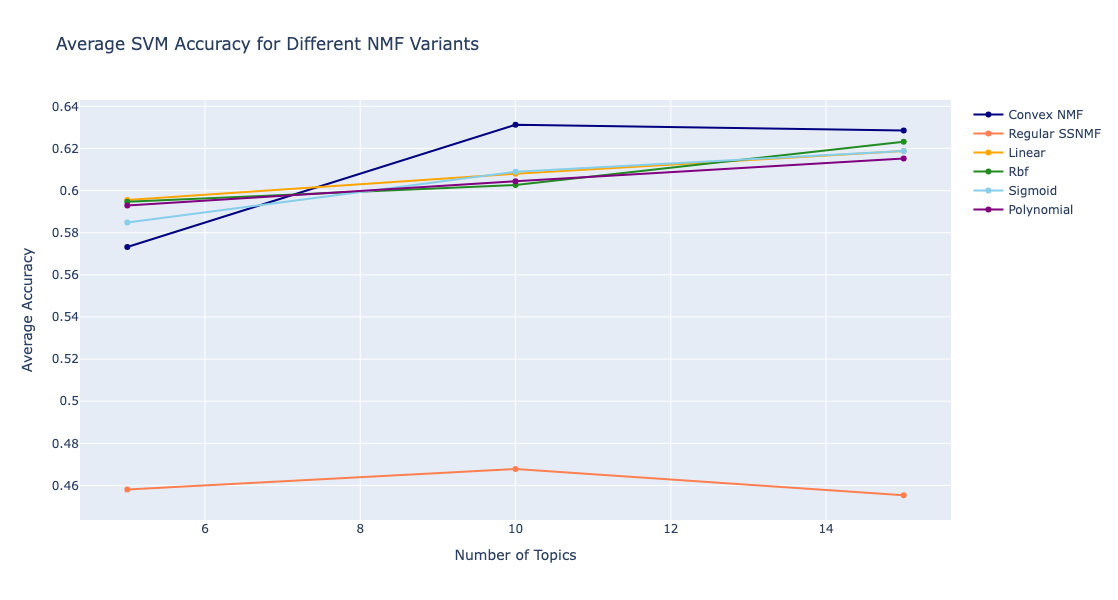

In [53]:
# Calculate average scores for each kernel and number of topics
avg_scores = {kernel: [] for kernel in kernel_colors.keys()}
num_topics = list(kernel_results.keys())

for topic in num_topics:
    for kernel in kernel_colors.keys():
        scores = kernel_results[topic][kernel]
        avg_score = sum(scores) / len(scores)
        avg_scores[kernel].append(avg_score)

# Create a line plot for average scores
fig = go.Figure()

# Add line plot
fig.add_trace(go.Scatter(
    x=list(convex_avg.keys()),
    y=list(convex_avg.values()),
    mode='lines+markers',
    name='Convex NMF',
    line=dict(color='navy', width=2)
))

fig.add_trace(go.Scatter(
    x=list(ssnmf_avg.keys()),
    y=list(ssnmf_avg.values()),
    mode='lines+markers',
    name='Regular SSNMF',
    line=dict(color='coral', width=2)
))

for kernel, color in kernel_colors.items():
    fig.add_trace(go.Scatter(
        x=num_topics,
        y=avg_scores[kernel],
        mode='lines+markers',
        name=kernel.capitalize(),
        line=dict(color=color),
        marker=dict(symbol='circle')
    ))

# Update layout
fig.update_layout(
    title="Average SVM Accuracy for Different NMF Variants",
    xaxis_title="Number of Topics",
    yaxis_title="Average Accuracy",
    height=600,
    width=800
)

# Show plot
fig.show()

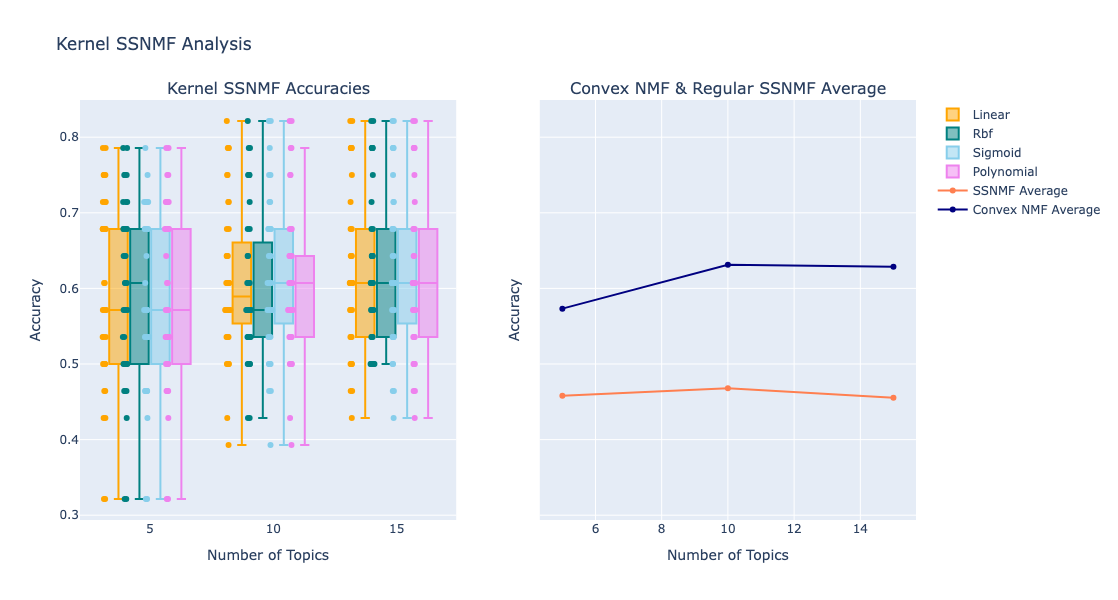

In [54]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Define kernel colors for differentiation
kernel_colors = {
    'linear': 'orange',
    'rbf': 'teal',
    'sigmoid': 'skyblue',
    'polynomial': 'violet'
}

# Define width of each group of boxes and spacing between kernels
box_width = 0.15
kernel_offset = 0.17

# Create subplots: one for the box plots, one for the line plot
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=["Kernel SSNMF Accuracies", "Convex NMF & Regular SSNMF Average"],
    shared_yaxes=True  # Share y-axis between subplots
)

# Add box plots
for i, key in enumerate(kernel_results.keys()):
    for j, kernel in enumerate(kernel_colors.keys()):
        y_values = kernel_results[key][kernel]
        
        # Calculate x position with offset for spacing
        x_pos = i + j * kernel_offset
        
        fig.add_trace(go.Box(
            y=y_values,
            name=kernel.capitalize(),
            boxpoints='all',
            marker_color=kernel_colors[kernel],
            x=[x_pos] * len(y_values),
            width=box_width,
            showlegend=(i == 0)  # Show legend only for the first set of boxes
        ), row=1, col=1)

# Add line plot
fig.add_trace(go.Scatter(
    x=list(ssnmf_avg.keys()),
    y=list(ssnmf_avg.values()),
    mode='lines+markers',
    name='SSNMF Average',
    line=dict(color='coral', width=2)
), row=1, col=2)

fig.add_trace(go.Scatter(
    x=list(convex_avg.keys()),
    y=list(convex_avg.values()),
    mode='lines+markers',
    name='Convex NMF Average',
    line=dict(color='navy', width=2)
), row=1, col=2)

# Update layout
fig.update_layout(
    title="Kernel SSNMF Analysis",
    xaxis_title="Number of Topics",
    yaxis_title="Accuracy",
    xaxis=dict(
        tickvals=[i + (len(kernel_colors) - 1) * kernel_offset / 2 for i in range(len(kernel_results.keys()))],
        ticktext=[str(key) for key in kernel_results.keys()]
    ),
    boxmode='group',  # Group the boxes together
    height=600,
    width=1100,  # Increase width to accommodate both plots
    showlegend=True
)

# Update subplot titles and axis labels
fig.update_xaxes(title_text="Number of Topics", row=1, col=1)
fig.update_yaxes(title_text="Accuracy", row=1, col=1)
fig.update_xaxes(title_text="Number of Topics", row=1, col=2)
fig.update_yaxes(title_text="Accuracy", row=1, col=2)

# Show plot
fig.show()


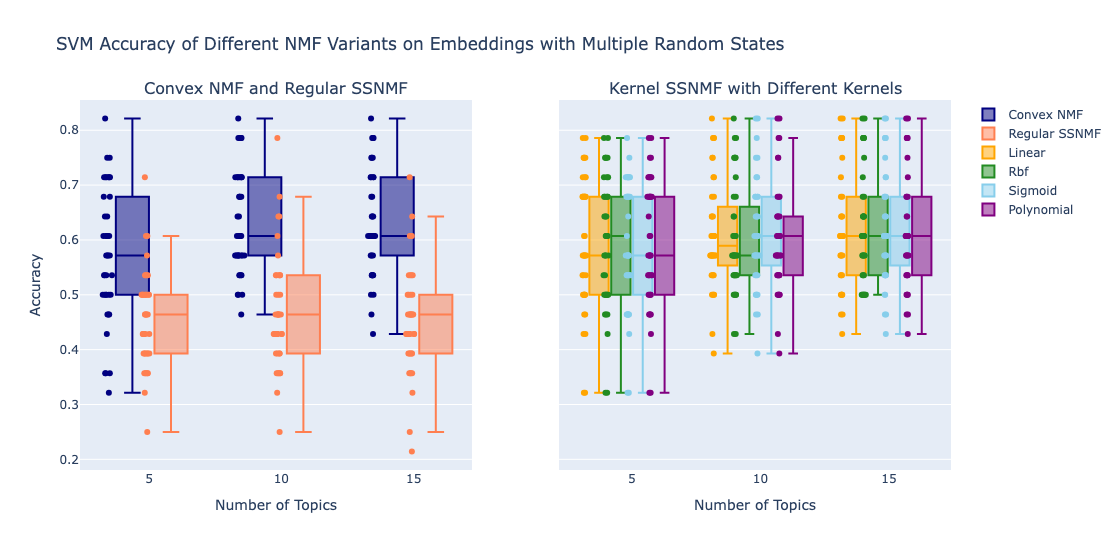

In [55]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Create subplots: one row, two columns
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Convex NMF and Regular SSNMF", 
                    "Kernel SSNMF with Different Kernels"),
    shared_yaxes=True  # Share y-axis across subplots
)

# Define spacing between groups
spacing = 0.2

# Add traces for the first subplot (left side)
for i, key in enumerate(convex_results.keys()):
    convex_values = convex_results[key]
    ssnmf_values = ssnmf_results[key]
    
    # Calculate x position with spacing
    x_position = i * (1 + spacing)
    
    fig.add_trace(go.Box(
        y=convex_values,
        name='Convex NMF' if i == 0 else None,
        boxpoints='all',
        marker_color='navy',
        x=[x_position] * len(convex_values),
        width=0.3, 
        showlegend=(i == 0)
    ), row=1, col=1)
    
    fig.add_trace(go.Box(
        y=ssnmf_values,
        name='Regular SSNMF' if i == 0 else None,
        boxpoints='all',
        marker_color='coral',
        x=[x_position + 0.35] * len(ssnmf_values),
        width=0.3, 
        showlegend=(i == 0)
    ), row=1, col=1)

# Define kernel colors for differentiation
kernel_colors = {
    'linear': 'orange',
    'rbf': 'forestgreen',
    'sigmoid': 'skyblue',
    'polynomial': 'purple'
}

# Define width of each group of boxes and spacing between kernels
box_width = 0.15
kernel_offset = 0.17

# Add traces for the second subplot (right side)
for i, key in enumerate(kernel_results.keys()):
    for j, kernel in enumerate(kernel_colors.keys()):
        y_values = kernel_results[key][kernel]
        
        # Calculate x position with offset for spacing
        x_pos = i + j * kernel_offset
        
        fig.add_trace(go.Box(
            y=y_values,
            name=kernel.capitalize(),
            boxpoints='all',
            marker_color=kernel_colors[kernel],
            x=[x_pos] * len(y_values),
            width=box_width,
            showlegend=(i == 0)  # Show legend only for the first set of boxes
        ), row=1, col=2)

# Update layout for subplots
fig.update_layout(
    title="SVM Accuracy of Different NMF Variants on Embeddings with Multiple Random States",
    xaxis_title="Number of Topics",
    xaxis2_title="Number of Topics",
    yaxis_title="Accuracy",
    xaxis=dict(
        tickvals=[i * (1 + spacing) + 0.15 for i in range(len(convex_results))],
        ticktext=[str(key) for key in convex_results.keys()]
    ),
    xaxis2=dict(
        tickvals=[i + (len(kernel_colors) - 1) * kernel_offset / 2 for i in range(len(kernel_results.keys()))],
        ticktext=[str(key) for key in kernel_results.keys()]
    ),
    height=550,
    width=1100
)

# Show plot
fig.show()
